Функция            : Розенброк
Стартовая точка    : [0.3, 0.2]
Найденный минимум  : x* = [1.0, 1.0]
f(x*)              = 0.0
Итераций           : 7
Точек в последовательности: 8
------------------------------------------------------------
Функция            : Растригин
Стартовая точка    : [0.1, 0.1]
Найденный минимум  : x* = [0.0, 0.0]
f(x*)              = 0.0
Итераций           : 2
Точек в последовательности: 3
------------------------------------------------------------
Функция            : Швефель
Стартовая точка    : [420.0, 419.0]
Найденный минимум  : x* = [420.968745, 420.968746]
f(x*)              = 2.54551e-5
Итераций           : 2
Точек в последовательности: 3
------------------------------------------------------------


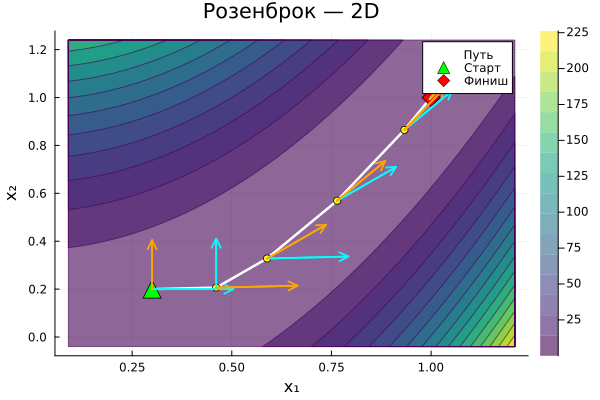

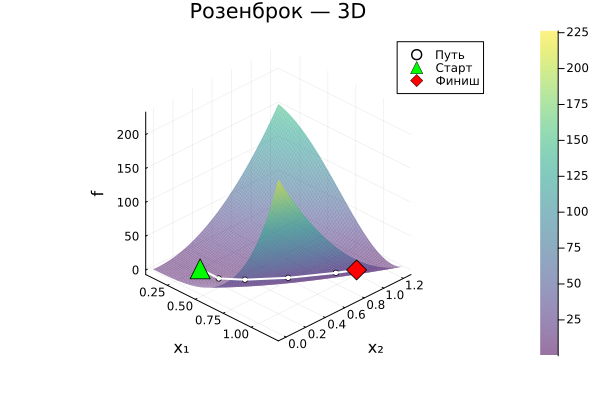

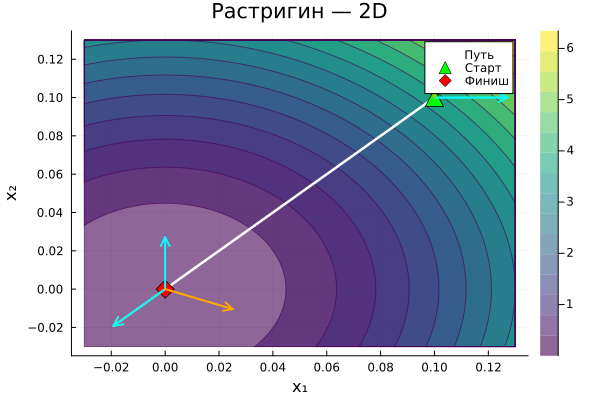

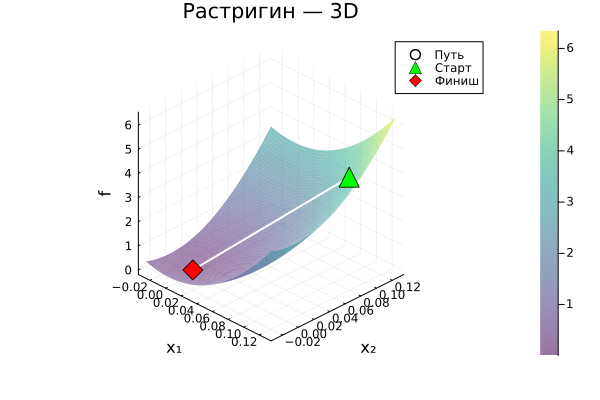

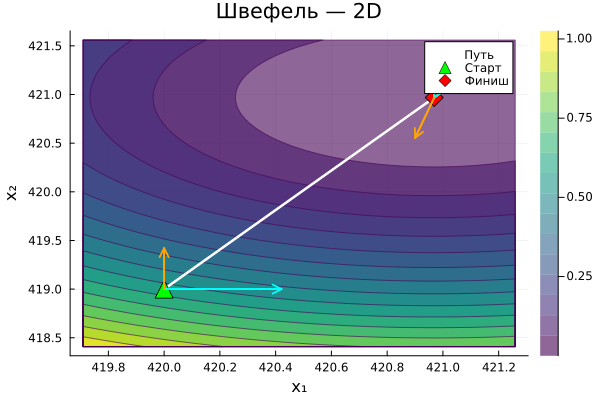

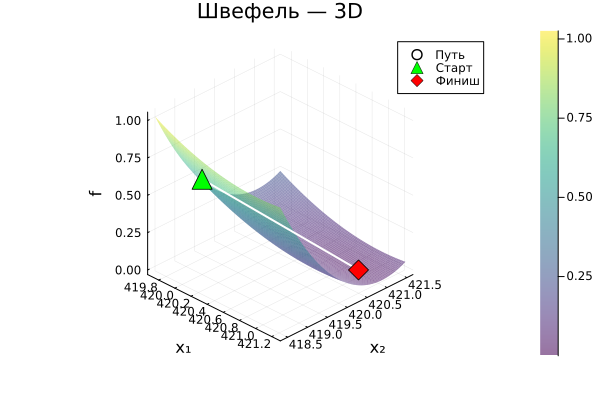

In [3]:
using LinearAlgebra
using Plots
gr()


f_rosen(p; a=1.0, b=100.0) = (a - p[1])^2 + b*(p[2] - p[1]^2)^2
f_rast(p; A=10.0)           = 2A + (p[1]^2 - A*cos(2π*p[1])) + (p[2]^2 - A*cos(2π*p[2]))
f_schwef(p)                 = 418.9829*2 - (p[1]*sin(sqrt(abs(p[1]))) + p[2]*sin(sqrt(abs(p[2]))))


function sven(g, x0; h=0.01, maxiter=80)
    f0 = g(x0)
    f1 = g(x0 + h)

    if f1 > f0
        h  = -h
        f1 = g(x0 + h)

        if f1 > f0
            lo = min(x0 - abs(h), x0 + abs(h))
            hi = max(x0 - abs(h), x0 + abs(h))
            return (lo, hi)
        end
    end

    x_prev, f_prev = x0,      f0
    x_curr, f_curr = x0 + h,  f1

    for k in 1:maxiter
        h2     = h * 2.0^k
        x_next = x0 + h2
        f_next = g(x_next)

        if f_next >= f_curr
            return (min(x_prev, x_next), max(x_prev, x_next))
        end

        x_prev, f_prev = x_curr, f_curr
        x_curr, f_curr = x_next, f_next
    end

    return (min(x_prev, x_curr), max(x_prev, x_curr))
end


function fib_search(g, a, b; tol=1e-8)
    (b - a) <= tol && return (a + b) / 2

    F = [1, 1]
    while F[end] < (b - a) / tol
        push!(F, F[end] + F[end-1])
    end
    N = length(F)

    x1 = a + (F[N-2] / F[N]) * (b - a);  f1 = g(x1)
    x2 = a + (F[N-1] / F[N]) * (b - a);  f2 = g(x2)

    for k in 1:(N-3)
        if f1 > f2
            a  = x1;  x1 = x2;  f1 = f2
            x2 = a + (F[N-k-1] / F[N-k]) * (b - a);  f2 = g(x2)
        else
            b  = x2;  x2 = x1;  f2 = f1
            x1 = a + (F[N-k-2] / F[N-k]) * (b - a);  f1 = g(x1)
        end
    end

    return (a + b) / 2
end


function powell(f, x0; eps=1e-8, maxit=3000)
    n  = length(x0)
    xk = collect(Float64, x0)

    dirs      = [begin d = zeros(n); d[i] = 1.0; d end for i in 1:n]
    history   = [copy(xk)]
    dirs_hist = [deepcopy(dirs)]

    for iter in 1:maxit
        p0 = copy(xk)

        for j in 1:n
            d    = dirs[j]
            g    = α -> f(xk .+ α .* d)
            a, b = sven(g, 0.0)
            α    = fib_search(g, a, b)
            xk   = xk .+ α .* d
        end

        pn   = copy(xk)
        dnew = pn .- p0

        if norm(dnew) > 1e-14
            gnew = α -> f(xk .+ α .* dnew)
            a, b = sven(gnew, 0.0)
            α    = fib_search(gnew, a, b)
            xk   = xk .+ α .* dnew
        end

        push!(history, copy(xk))
        popfirst!(dirs)
        push!(dirs, dnew ./ max(norm(dnew), 1e-14))
        push!(dirs_hist, deepcopy(dirs))

        if abs(f(history[end]) - f(history[end-1])) < eps
            return xk, history, iter, dirs_hist
        end
    end

    return xk, history, maxit, dirs_hist
end


function split_xy(hist)
    return [Float64(p[1]) for p in hist], [Float64(p[2]) for p in hist]
end


function plot2d(f, history, dirs_hist; title="Powell 2D", gridN=250, pad=0.3, arrow_scale=0.12)
    xs, ys = split_xy(history)

    xmin, xmax = minimum(xs), maximum(xs)
    ymin, ymax = minimum(ys), maximum(ys)

    dx = max(xmax - xmin, 1e-6);  dy = max(ymax - ymin, 1e-6)
    xmin -= pad*dx;  xmax += pad*dx
    ymin -= pad*dy;  ymax += pad*dy

    xg = range(xmin, xmax; length=gridN)
    yg = range(ymin, ymax; length=gridN)
    Z  = [f((x, y)) for y in yg, x in xg]

    pl = contourf(xg, yg, Z; color=:viridis, alpha=0.6,
                  xlabel="x₁", ylabel="x₂", title=title, legend=:topright, colorbar=true)

    plot!(pl, xs, ys; lw=2.5, color=:white, label="Путь")
    scatter!(pl, xs[2:end-1], ys[2:end-1]; ms=4, color=:yellow, label="")
    scatter!(pl, [xs[1]],   [ys[1]];   ms=9, color=:lime, markershape=:utriangle, label="Старт")
    scatter!(pl, [xs[end]], [ys[end]]; ms=9, color=:red,  markershape=:diamond,   label="Финиш")

    diag         = sqrt((xmax-xmin)^2 + (ymax-ymin)^2)
    L            = arrow_scale * diag
    arrow_colors = [:cyan, :orange, :magenta, :lime]
    m            = min(length(history), length(dirs_hist))

    for i in 1:m
        base = history[i]
        for (ci, d) in enumerate(dirs_hist[i])
            dn  = d ./ max(norm(d), 1e-12)
            ex  = base[1] + L*dn[1]
            ey  = base[2] + L*dn[2]
            col = arrow_colors[mod1(ci, length(arrow_colors))]
            plot!(pl, [base[1], ex], [base[2], ey]; lw=1.8, color=col, arrow=true, label="")
        end
    end

    return pl
end


function plot3d(f, history; title="Powell 3D", gridN=80, pad=0.3)
    xs, ys = split_xy(history)

    xmin, xmax = minimum(xs), maximum(xs)
    ymin, ymax = minimum(ys), maximum(ys)

    dx = max(xmax - xmin, 1e-6);  dy = max(ymax - ymin, 1e-6)
    xmin -= pad*dx;  xmax += pad*dx
    ymin -= pad*dy;  ymax += pad*dy

    xg = range(xmin, xmax; length=gridN)
    yg = range(ymin, ymax; length=gridN)
    Z  = [f((x, y)) for y in yg, x in xg]

    pl = surface(xg, yg, Z; color=:viridis, alpha=0.55,
                 xlabel="x₁", ylabel="x₂", zlabel="f",
                 title=title, legend=:topright, camera=(45, 30))

    zs = [Float64(f(p)) for p in history]

    scatter!(pl, xs[2:end-1], ys[2:end-1], zs[2:end-1]; ms=3, color=:white, label="Путь")
    plot!(pl, xs, ys, zs; lw=2, color=:white, label="")
    scatter!(pl, [xs[1]],   [ys[1]],   [zs[1]];   ms=10, color=:lime, markershape=:utriangle, label="Старт")
    scatter!(pl, [xs[end]], [ys[end]], [zs[end]]; ms=10, color=:red,  markershape=:diamond,   label="Финиш")

    return pl
end


cases = [
    ("Розенброк", f_rosen,  [0.3,   0.2  ]),
    ("Растригин", f_rast,   [0.1,   0.1  ]),
    ("Швефель",   f_schwef, [420.0, 419.0]),
]

results = []

for (name, f, x0) in cases
    xmin, hist, iters, dirs = powell(f, x0)
    push!(results, (name, f, xmin, hist, iters, dirs))
end

println("=" ^ 60)
for (name, f, xmin, hist, iters, dirs) in results
    println("Функция            : $name")
    println("Стартовая точка    : $(round.(hist[1]; digits=6))")
    println("Найденный минимум  : x* = $(round.(xmin; digits=6))")
    println("f(x*)              = $(round(f(xmin); digits=10))")
    println("Итераций           : $iters")
    println("Точек в последовательности: $(length(hist))")
    println("-" ^ 60)
end

for (name, f, xmin, hist, iters, dirs) in results
    display(plot2d(f, hist, dirs; title="$name — 2D"))
    display(plot3d(f, hist;       title="$name — 3D"))
end